<h1 style="text-align: center;">Projet de machine learning : Prédiction des résultats de sessions des étudiants</h1>

<h5 style="text-align: center;"> Auteur : BARGO Alfred</h5>

## Introduction

Dans le domaine éducatif, il y a parfois ce travail pénible pour l'administration, de faire les délibérations des sessions d'examens estudiantines pour des promotions massifs. Avec chaque module ayant un poids différent sur le résultat académique de l'étudiant, ce travail d'extraction peu paraître long et fatiguant. D'un autre côté aussi, il serait plus intéressant de permettre à l'étudiant en fonction de l'évolution de ses notes, de prédire déjà quel pourrait-être son résultat afin de revoir sa façon d'apprendre si nécessaire.

C'est dans cette perspective que nous construisons dans ce projet, un modèle d'apprentissage machine qui permet de prédire efficacement le résultat de la session d'un étudiant à partir de ses notes pondérées.

Pour cela, nous commençons d'abord par le chargement et l'analyse exploratoire des données. Nous poursuivons avec le prétraîtement des données. Nous construisons, entraînons et évaluons le modèle par la suite. Enfin, nous construisons une interface de prédiction locale.

<h3 style="text-align: center;"> Chargement des bibliothèques</h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve, validation_curve, cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline   
from collections import Counter
import joblib
import warnings
import ipywidgets as widgets
from IPython.display import display, clear_output
from IPython.display import display, clear_output, HTML

%%html
<style>
.jp-Cell { margin-bottom: 25px !important; }
</style>

---

# I. Analyse et exploration des données (EDA)

## I.1 Chargement des données 

In [2]:
df=pd.read_excel("Data_training.xlsx")

## I.2 Analyse de la forme

* **Affichage d'un aperçu**

In [3]:
df.head()

,Moyenne Pondéré PHYSIQUE 2,Moyenne Pondéré MATHÉMATIQUES 2,Moyenne Pondéré CHIMIE 2,Moyenne Pondéré INFORMATIQUE 2,Moyenne Pondéré TRANSVERSALES 2,Moyenne Pondéré SCIENCES GRAPHIQUES,Total,Résultat
0,92.5,12.0,40.75,82.0,73.0,30.0,330.25,Validé
1,91.5,32.5,81.00,77.0,91.0,52.5,425.50,Validé
2,91.0,28.0,66.50,77.0,94.0,64.5,421.00,Validé
3,88.5,28.5,55.25,76.0,78.0,47.0,373.25,Validé
4,88.5,8.0,48.75,67.0,87.0,32.0,331.25,Validé


* **Dimension du jeu de données**

In [4]:
np.shape(df)

(1087, 8)

**Analyse :**

Le jeu de données est composée de 1087 instances et 8 caractéristiques (variables)

* **Types des variables**

In [5]:
df.dtypes

Moyenne Pondéré PHYSIQUE 2             float64
Moyenne Pondéré MATHÉMATIQUES 2        float64
Moyenne Pondéré CHIMIE 2               float64
Moyenne Pondéré INFORMATIQUE 2         float64
Moyenne Pondéré TRANSVERSALES 2        float64
Moyenne Pondéré SCIENCES GRAPHIQUES    float64
Total                                  float64
Résultat                                object
dtype: object

**Analyse :**

Il y a 7 variables numériques dans le jeu de données et une variable non numérique(caractères)

* **Identification de la variable cible**

In [6]:
df["Résultat"].unique()

array(['Validé', 'Non validé'], dtype=object)

La variable cible est "**Résultat"**. Il s'agit d'une variable catégorielle binaire prenant les valeurs "**Validé**" et "**Non validé**"

* **Analyse de la présence de données manquantes**

In [7]:
# Pourcentage de NA dans chaque variable
df.isna().sum()/df.shape[0]
# Trie selon un ordre ascendant
(df.isna().sum()/df.shape[0]).sort_values(ascending=True)

Moyenne Pondéré PHYSIQUE 2             0.0
Moyenne Pondéré MATHÉMATIQUES 2        0.0
Moyenne Pondéré CHIMIE 2               0.0
Moyenne Pondéré INFORMATIQUE 2         0.0
Moyenne Pondéré TRANSVERSALES 2        0.0
Moyenne Pondéré SCIENCES GRAPHIQUES    0.0
Total                                  0.0
Résultat                               0.0
dtype: float64

**Interprétation**:

En résumé, le jeu de données ne contient pas de données manquantes.

* **Résumé statistique du jeu de données**

In [8]:
df.describe()

,Moyenne Pondéré PHYSIQUE 2,Moyenne Pondéré MATHÉMATIQUES 2,Moyenne Pondéré CHIMIE 2,Moyenne Pondéré INFORMATIQUE 2,Moyenne Pondéré TRANSVERSALES 2,Moyenne Pondéré SCIENCES GRAPHIQUES,Total
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,30.508740,8.429531,30.080819,33.309568,38.684913,23.496780,164.510350
std,27.873921,9.211934,24.839574,29.282536,31.252371,22.211403,132.349201
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,32.500000,7.500000,37.500000,39.000000,47.000000,22.500000,199.250000
75%,54.500000,14.000000,52.000000,60.000000,66.000000,42.500000,282.875000
max,92.500000,51.000000,81.000000,88.000000,98.000000,79.000000,425.500000


**Interprétation :**

Ce résumé affiche les statistiques de bases sur les données telles que la moyenne, l'écart-type et les différents quartiles de la loi normale.<br>
On peut remarquer à l'issu de cet affichage que le nombres d'instances est identique et égale à 1080 pour tous les variables, confirmant l'absence de données manquantes et que les moyennes des variables sont différentes (différence parfois large).

## I.3 Analyse du fond

### I.3.1 Visualisation de la répartition des classes de la variable cible

In [9]:
def class_distribution(df, class_column='target'):
    # Calcul du décompte des classes
    distribution = df[class_column].value_counts().sort_index()
    
    percentages = (df[class_column].value_counts(normalize=True) * 100).sort_index()
    result = pd.DataFrame({
        'Nombre': distribution,
        'Pourcentage': percentages.round(2)
    })
    result.loc['Total'] = [result['Nombre'].sum(), result['Pourcentage'].sum()]
    return result

class_distribution(df, class_column='Résultat')

,Nombre,Pourcentage
Résultat,,
Non validé,880.0,80.96
Validé,207.0,19.04
Total,1087.0,100.00


**Analyse :**

Il y a au total dans le jeu de données, 207 instances appartenant à la classe "**Validé**" et 880 instances appartenant à la classe "**Non validé**". En terme de pourcentage, plus de 80% des données appartiennent à la classe **"Non validé"**. 

**Interprétation :**

Les classes du jeu de données sont déséquilibrées.

* **Visualisation graphique du déséquilibre**

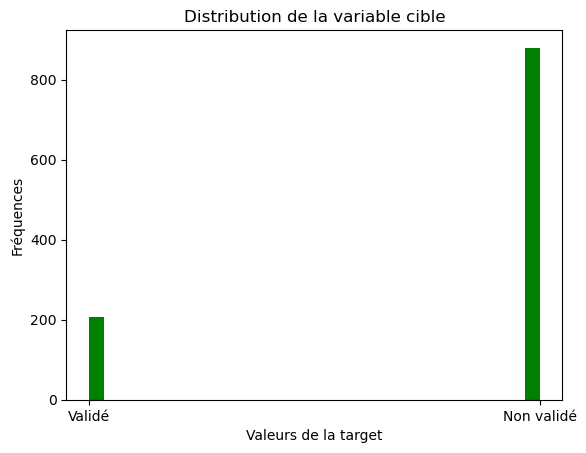

In [10]:
plt.hist(df['Résultat'],bins=30, color='green')
plt.xlabel('Valeurs de la target')
plt.ylabel('Fréquences')
plt.title('Distribution de la variable cible')
plt.show()

## I.3.2 Analyses des distributions des variables numériques(Histogrammes)

In [11]:
def plot_custom_histogram(data, variable_name, bins=30, figsize=(7, 4),
                         hist_color='lightblue', curve_color='darkred',
                         mean_color='green', median_color='orange'):
    
    fig, ax = plt.subplots(figsize=figsize)
    data_array = np.array(data)
    
    if len(data_array) == 0:
        return
    
    # Calcul des statistiques
    mean_val = np.mean(data_array)
    median_val = np.median(data_array)
    
    # Histogramme
    ax.hist(data_array, bins=bins, edgecolor='black', 
            alpha=0.7, density=True, color=hist_color)
    
    # Courbe de densité
    kde = gaussian_kde(data_array)
    x_vals = np.linspace(data_array.min(), data_array.max(), 1000)
    ax.plot(x_vals, kde(x_vals), color=curve_color, linewidth=2.5)
    
    # Lignes de moyenne et médiane
    ax.axvline(mean_val, color=mean_color, linestyle='--', 
               linewidth=2, label=f'Moyenne: {mean_val:.2f}')
    ax.axvline(median_val, color=median_color, linestyle=':', 
               linewidth=2, label=f'Médiane: {median_val:.2f}')
    
    # Configuration
    ax.set_xlabel(variable_name)
    ax.set_ylabel('Densité')
    ax.set_title(f'Distribution de {variable_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

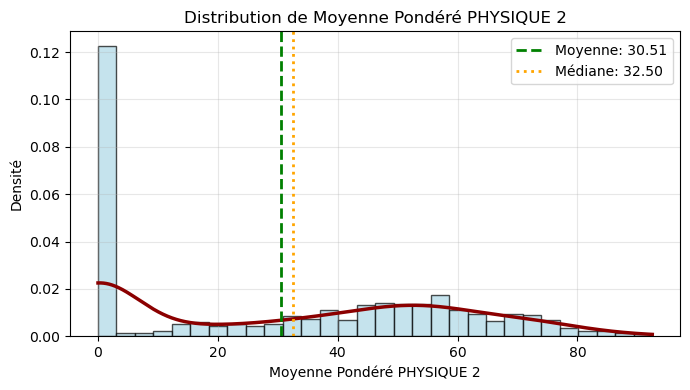

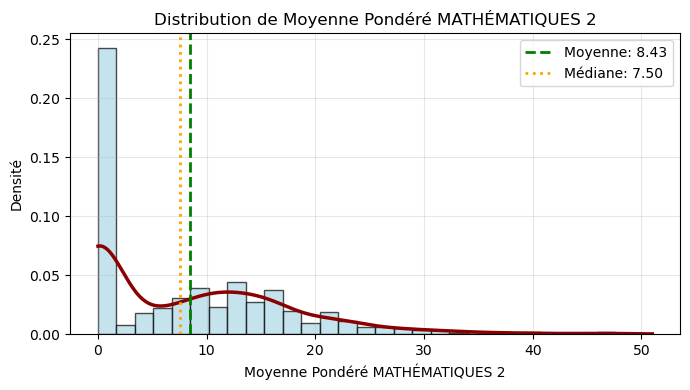

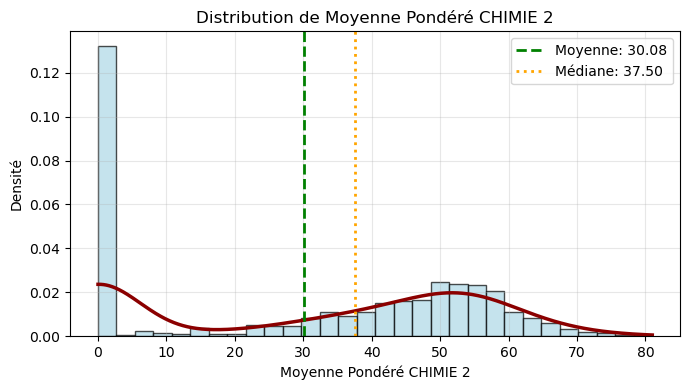

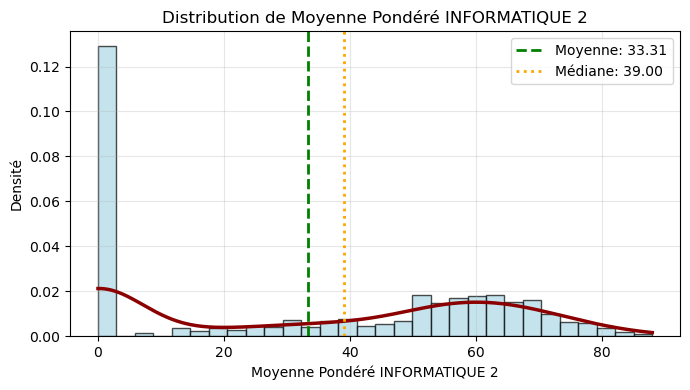

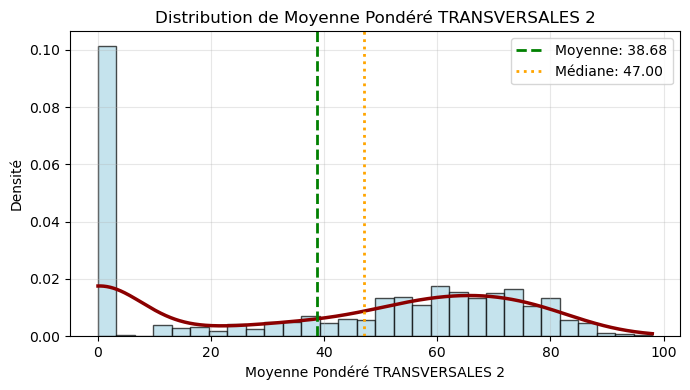

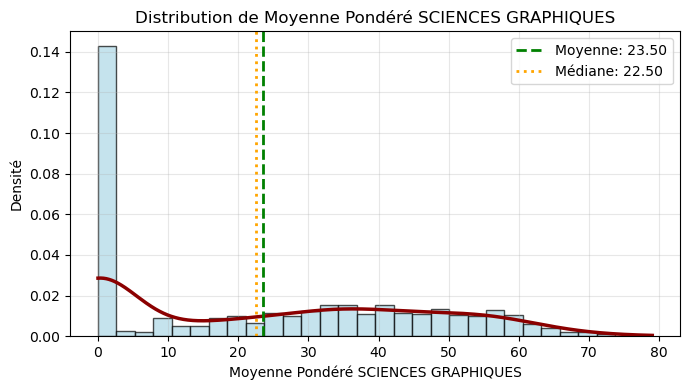

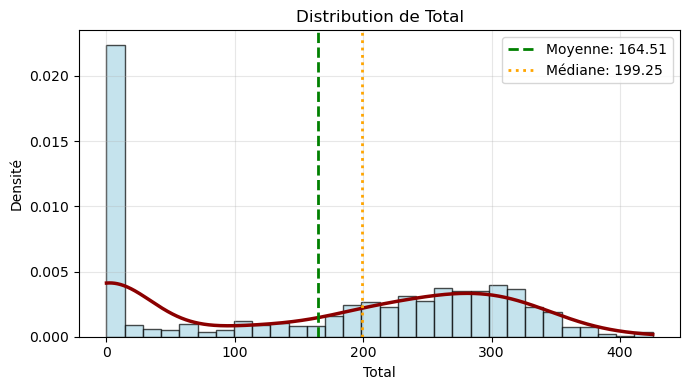

In [12]:
plot_custom_histogram(df["Moyenne Pondéré PHYSIQUE 2"], "Moyenne Pondéré PHYSIQUE 2", bins=30)
plot_custom_histogram(df["Moyenne Pondéré MATHÉMATIQUES 2"], "Moyenne Pondéré MATHÉMATIQUES 2", bins=30)
plot_custom_histogram(df["Moyenne Pondéré CHIMIE 2"], "Moyenne Pondéré CHIMIE 2", bins=30)
plot_custom_histogram(df["Moyenne Pondéré INFORMATIQUE 2"], "Moyenne Pondéré INFORMATIQUE 2", bins=30)
plot_custom_histogram(df["Moyenne Pondéré TRANSVERSALES 2"], "Moyenne Pondéré TRANSVERSALES 2", bins=30)
plot_custom_histogram(df["Moyenne Pondéré SCIENCES GRAPHIQUES"], "Moyenne Pondéré SCIENCES GRAPHIQUES", bins=30)
plot_custom_histogram(df["Total"], "Total", bins=30)

**Interprétation**

* **Moyenne Pondéré PHYSIQUE 2** :
Le graphique montre que les valeurs de cette variable ont une distribution asymétrique à gauche. La courbe présente deux pics à 0 et à 55. Quelques petites valeurs de dénsité élevée tirent la moyenne vers la gauche. On peut dire qu'un grand nombre d'étudiant ont une moyenne pondéré en Physique 2 inférieur à 20 ce qui explique la présence du premier pic de la courbe de distribution.
* **Moyenne Pondéré MATHÉMATIQUES 2**: Le graphique montre une distribution asymétrique à droite. Un premier pic de la courbe est atteint à 0 et un deuxième est atteint autour de 11. Le premier pic de la courbe se justifie par le fait qu'un grand nombre d'étudiants ont une Moyenne Pondéré MATHÉMATIQUES 2 faible (proche de zéro).
* **Moyenne Pondéré CHIMIE 2**: Le graphique montre une distribution asymétrique à gauche pour cette variable. De plus, la courbe de normalité présente deux pics à 0 et à 53. Le étudiants ont en moyenne 30,08 comme moyenne pondéré en Chimie 2. Le premier pic à zéro signifie qu'un grand nombre d'étudiants ont une moyenne pondéré en chimie 2 faible (inférieur à 10).
* **Moyenne Pondéré INFORMATIQUE 2**: La *Moyenne Pondéré INFORMATIQUE 2* des étudiant présente une distribution asymétrique à gauche avec deux pics l'une à 0 et l'autre à 60. En moyenne, les étudiants ont 33,31 comme moyenne pondéré dans cet module et grand nombre parmi eux ont une moyenne pondéré Informatique 2 faible (proche de zéro) ce qui attire la moyenne générale la rendant faible.
* **Moyenne Pondéré TRANSVERSALES 2**: Cette variable présente une distribution asymétrique à gauche. La courbe de normalité affiche deux pics, l'une à zéro et l'autre autour de 70. Un grand nombre d'étudiants ont une moyenne pondéré Transversales 2 faible, ce qui attire la moyenne générale vers une valeur basse proche de zéro.
* **Moyenne Pondéré SCIENCES GRAPHIQUES**: Cette variable présente une distribution légèrement asymétrique à droite. La courbe présente deux pics dont le premier (à zéro) traduit le fait qu'un nombre important d'étudiants ont une Moyenne Pondéré SCIENCES GRAPHIQUES très faible.
* **Total**: La courbe de distribution de cette variable montre qu'elle a une distribution asymétrique à gauche. On remarque la présence de deux pics dans la courbe et le premier est à zéro (le plus fort), signifiant que la grande majorité des étudiants ont un Total de leurs moyennes pondéré faible, attirant ainsi la moyenne générale vers une faible valeur.  

### I.3.3 Représentation des boîtes à moustaches des variables numériques

In [13]:
warnings.filterwarnings("ignore")
def plot_multiple_boxplots(dataframe, columns=None, figsize=(12, 6)):
    
    # Sélection des colonnes
    if columns is None:
        # Sélection automatique des colonnes numériques
        numeric_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) == 0:
            print("Aucune colonne numérique trouvée.")
            return
        columns = numeric_cols
    
    # Filtrage pour n'afficher que les colonnes existantes
    columns = [col for col in columns if col in dataframe.columns]
    if len(columns) == 0:
        print("Aucune des colonnes spécifiées n'existe dans le DataFrame.")
        return
    
    # Création de la figure
    n_cols = len(columns)
    fig, ax = plt.subplots(figsize=figsize)
    
    # Préparation des données pour boxplot
    plot_data = [dataframe[col].dropna() for col in columns]
    
    # Création du boxplot multiple
    bp = ax.boxplot(plot_data, vert=True, patch_artist=True,
                   labels=columns,
                   boxprops=dict(facecolor='lightblue', color='black'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'),
                   flierprops=dict(marker='o', markerfacecolor='red', 
                                  markersize=5, alpha=0.5))
    
    # Ajout de couleurs différentes pour chaque boxplot
    colors = plt.cm.Set3(np.linspace(0, 1, n_cols))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Configuration
    ax.set_ylabel('Valeurs')
    ax.set_title('Boxplots des Variables Numériques')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Rotation des labels si nécessaire
    if n_cols > 5:
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

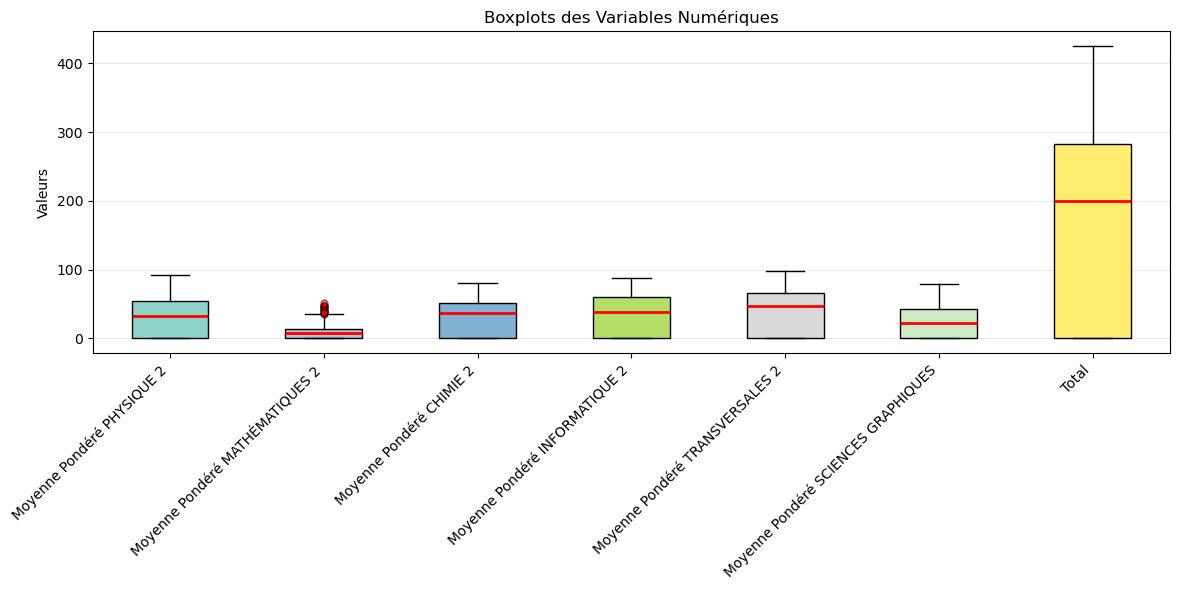

In [14]:
plot_multiple_boxplots(df)

**Analyse :** 

L'affichage des boxplots des différentes variables numériques montre que seule la variable **"Moyenne Pondéré MATHÉMATIQUES 2"** présente quelques valeurs abérrantes. 

Chaque variable a une distribution différente de l'autre, allant des variables avec une faible dispersion des valeurs autour de la moyenne à des variable avec une forte dispersion (*"Total"*) indiquant une large gamme de valeurs possible.

### I.3.4 Analyse de la multicolinéarité entre les variables numériques

🔍 ANALYSE DE LA VARIABLE 'Total' - RELATION AVEC LES MOYENNES PONDEREES

1. ✅ VÉRIFICATION DE LA SOMME:
   🔴 CONFIRMÉ: Total = somme des 6 notes
   Exemple étudiant 0: [92.5  12.   40.75 82.   73.   30.  ] → Total = 330.2
   Calculé: 330.2

3. 📊 ANALYSE DE MULTICOLINÉARITÉ:
                           Variable  VIF
         Moyenne Pondéré PHYSIQUE 2  inf
    Moyenne Pondéré MATHÉMATIQUES 2  inf
           Moyenne Pondéré CHIMIE 2  inf
     Moyenne Pondéré INFORMATIQUE 2  inf
    Moyenne Pondéré TRANSVERSALES 2  inf
Moyenne Pondéré SCIENCES GRAPHIQUES  inf
                              Total  inf

   🔴 VIF de 'Total' = inf > 10
   → Problème sérieux de multicolinéarité

4. 🎨 VISUALISATION DE LA RELATION:


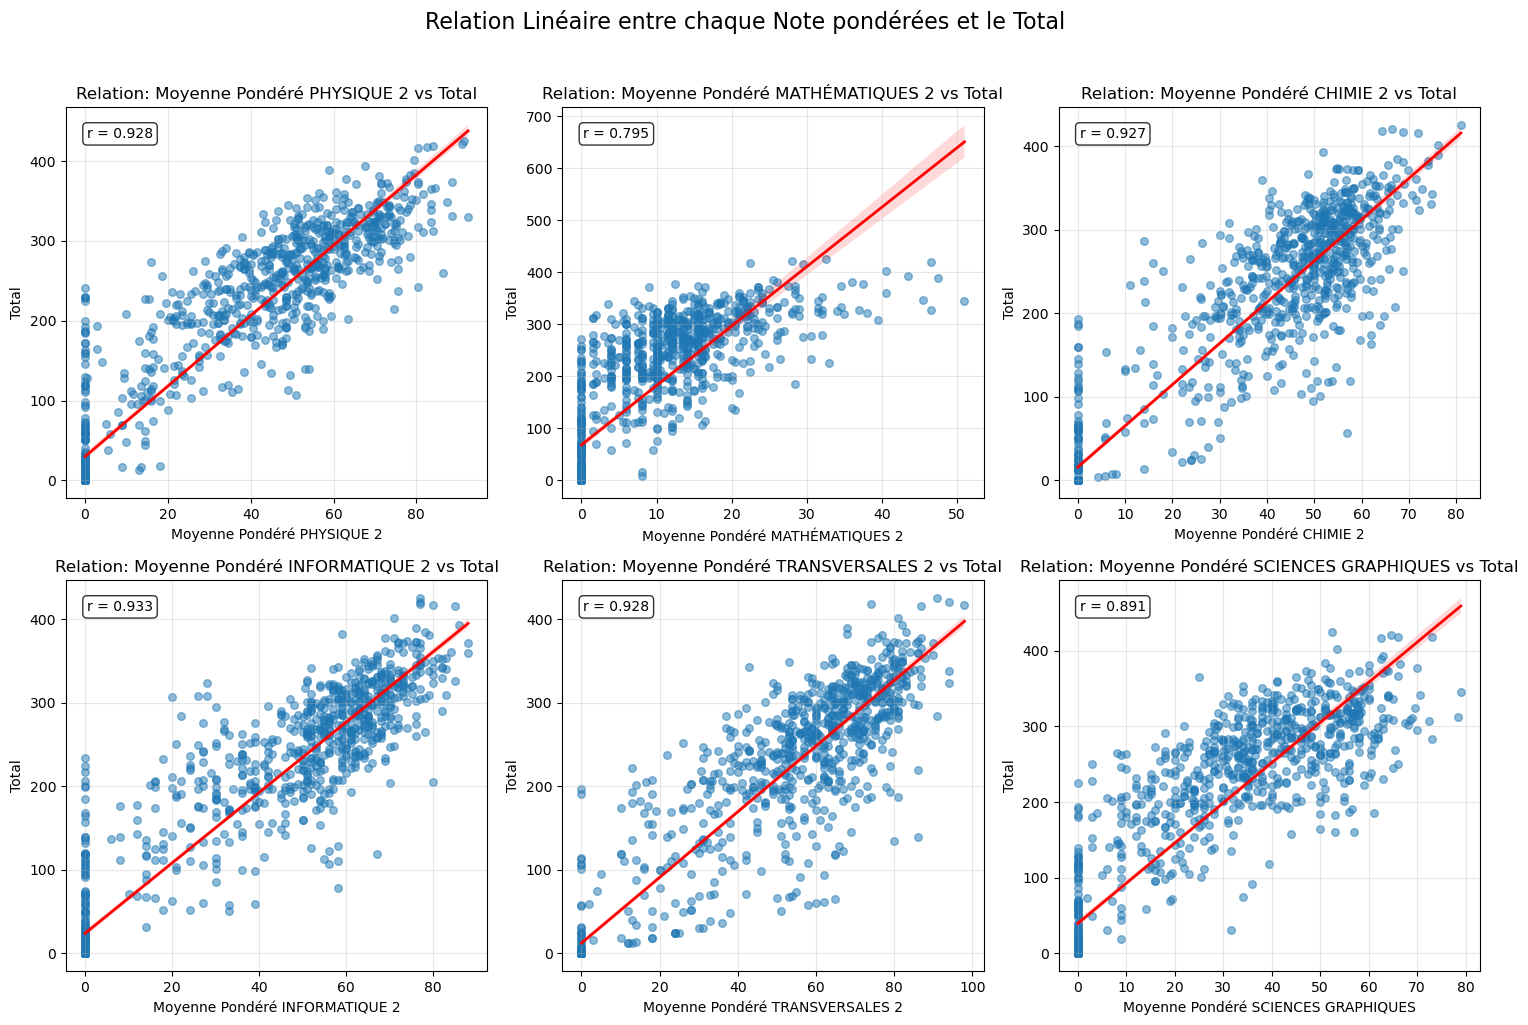

In [15]:
def analyze_total_relationship(df, note_columns, total_column, target_column):
    
    print("="*80)
    print("🔍 ANALYSE DE LA VARIABLE 'Total' - RELATION AVEC LES MOYENNES PONDEREES")
    print("="*80)
    
    # 1. Vérification que Total = somme des notes
    print("\n1. ✅ VÉRIFICATION DE LA SOMME:")
    
    # Calculer la somme des notes pour chaque étudiant
    calculated_total = df[note_columns].sum(axis=1)
    
    # Vérifier l'égalité (avec tolérance pour arrondis)
    equality_check = np.allclose(df[total_column], calculated_total)
    
    if equality_check:
        print("   🔴 CONFIRMÉ: Total = somme des 6 notes")
        print(f"   Exemple étudiant 0: {df[note_columns].iloc[0].values} → Total = {df[total_column].iloc[0]:.1f}")
        print(f"   Calculé: {calculated_total.iloc[0]:.1f}")
    else:
        print("   ⚠️  Total ≠ somme exacte des notes")
    
    # 3. Analyse de la colinéarité
    print("\n3. 📊 ANALYSE DE MULTICOLINÉARITÉ:")
    
    # VIF (Variance Inflation Factor) - version simplifiée
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    vif_data = pd.DataFrame()
    vif_data["Variable"] = note_columns + [total_column]
    
    try:
        X_temp = df[note_columns + [total_column]]
        vif_data["VIF"] = [variance_inflation_factor(X_temp.values, i) 
                          for i in range(len(X_temp.columns))]
        
        print(vif_data.to_string(index=False))
        
        # Interprétation
        vif_total = vif_data[vif_data['Variable'] == total_column]['VIF'].values[0]
        if vif_total > 10:
            print(f"\n   🔴 VIF de '{total_column}' = {vif_total:.1f} > 10")
            print("   → Problème sérieux de multicolinéarité")
        elif vif_total > 5:
            print(f"\n   🟡 VIF de '{total_column}' = {vif_total:.1f} > 5")
            print("   → Multicolinéarité modérée")
        else:
            print(f"\n   🟢 VIF de '{total_column}' = {vif_total:.1f}")
            print("   → Pas de problème majeur de colinéarité")
            
    except Exception as e:
        print(f"   ⚠️  Impossible de calculer VIF: {e}")
    
    # 4. Visualisation de la relation linéaire
    print("\n4. 🎨 VISUALISATION DE LA RELATION:")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, note in enumerate(note_columns[:6]):  # Limiter à 6 matières
        ax = axes[i]
        
        # Scatter plot avec régression linéaire
        sns.regplot(x=note, y=total_column, data=df, ax=ax, 
                   scatter_kws={'alpha': 0.5, 's': 30},
                   line_kws={'color': 'red', 'linewidth': 2})
        
        # Coefficient de corrélation
        corr = df[note].corr(df[total_column])
        ax.text(0.05, 0.95, f'r = {corr:.3f}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_title(f'Relation: {note} vs Total', fontsize=12)
        ax.set_xlabel(note)
        ax.set_ylabel('Total')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Relation Linéaire entre chaque Note pondérées et le Total', 
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

note_pondere_col=['Moyenne Pondéré PHYSIQUE 2', 'Moyenne Pondéré MATHÉMATIQUES 2',
       'Moyenne Pondéré CHIMIE 2', 'Moyenne Pondéré INFORMATIQUE 2',
       'Moyenne Pondéré TRANSVERSALES 2',
       'Moyenne Pondéré SCIENCES GRAPHIQUES']
analyze_total_relationship(df, note_pondere_col, "Total", "Résultat")

**Analyse :**

D'après ces afficages, la variable *"Total"* est typiquement la somme des notes pondérées des 6 matières. L'analyse de la multicolinéarité donne un coefficient VIF ([Variance Inflation Factor](https://en.wikipedia.org/wiki/Variance_inflation_factor)) supérieur à 10. <br>
Les représentations graphique montrent l'existence de relation linéaire entre les variables numériques et *"Total"*.

**Interprétation :**

Il y a multicolinéarité entre les variables explicatives du jeu de données.

### I.3.5 Graphiques des rélations variable/target

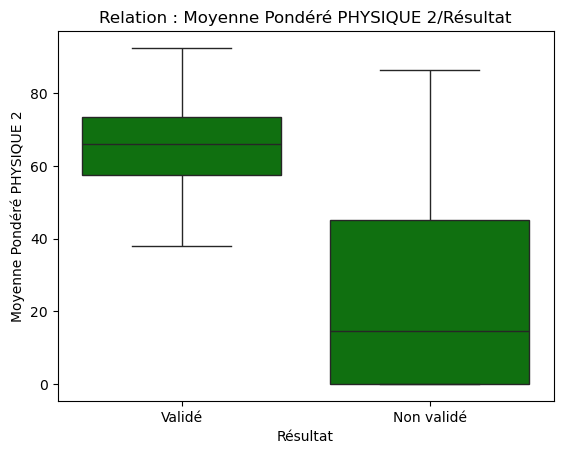

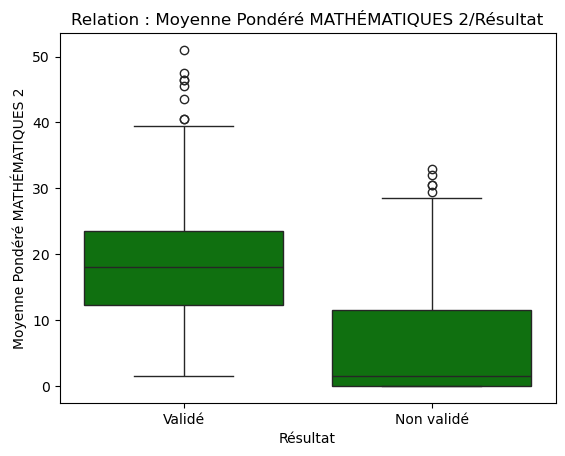

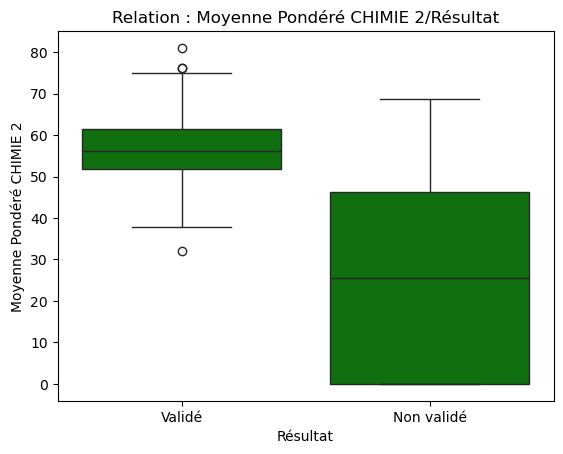

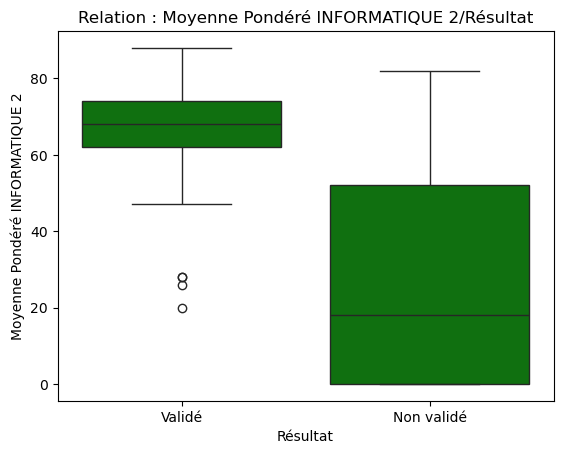

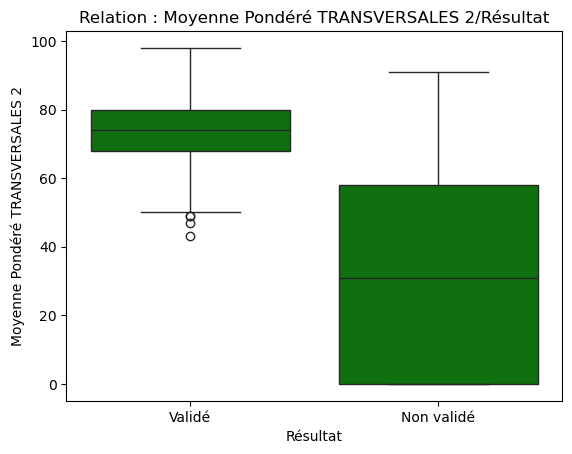

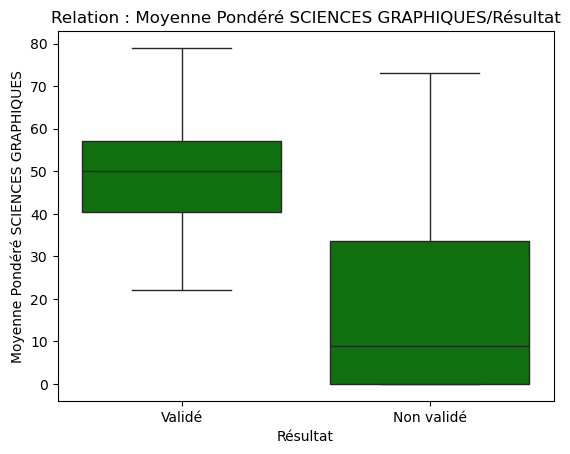

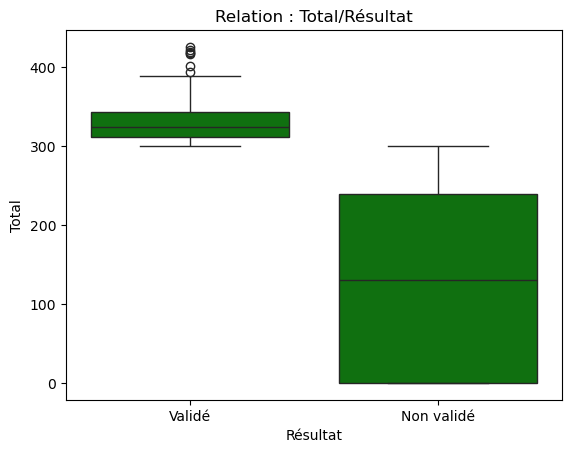

In [16]:
numeric_column=['Moyenne Pondéré PHYSIQUE 2', 'Moyenne Pondéré MATHÉMATIQUES 2',
       'Moyenne Pondéré CHIMIE 2', 'Moyenne Pondéré INFORMATIQUE 2',
       'Moyenne Pondéré TRANSVERSALES 2',
       'Moyenne Pondéré SCIENCES GRAPHIQUES', 'Total']
for col in numeric_column:
    sns.boxplot( x="Résultat", y=col, data=df, color='green')

    plt.title(f"Relation : {col}/Résultat")
    plt.xlabel("Résultat")
    plt.ylabel(col)
    plt.show()


**Analyse et interprétation**

Ces graphiques permettent d'étudier les rélation entre les variables quantitatives et la variable cible pour ensuite identifier ceux qui apportent plus d'informations dans la détermination de la variable à prédire. 

* **Moyenne Pondéré PHYSIQUE 2/Résultat** : Le graphique des boxplots de la relation *Moyenne Pondéré PHYSIQUE 2/Résultat* montre nettement une grande différence des boxplots. En effet, on peut remarquer que la boîte pour la classe "Non validé" est non seulement plus etendu que celle de la classe "Validé" montrant un intervalle de valeur large, mais aussi ses valeurs sont plus faibles. Les médianes des deux distributions sont différentes de plus et les boîtes ne se chevauchent pas. On peut donc émettre l'hypothèse selon laquelle il existe une forte rélation entre ces deux variables.
*  **Moyenne Pondéré MATHÉMATIQUES 2/Résultat**: D'après le graphique les deux boxplots présentent quelques legères différence observées au niveau des medianes du nombre de valeurs abérrantes et des intervalles de valeurs de chaque boîte. Les étendues par contre des deux boîtes à moustaches ne sont pas très différentes et de plus, elles se rapprochent tendant à se chevaucher un peu. Nous pouvons dire que la variable *"Moyenne Pondéré MATHÉMATIQUES 2"* influence légèrement le *Résultat* des étudiants.
* **Moyenne Pondéré CHIMIE 2/Résultat**: Le graphique montre que la *"Moyenne Pondéré CHIMIE 2"* influence le *"Résultat"* de l'étudiant. En effet, les deux boîtes montrent des distributions différentes de la variable dans les deux classes. La classe "Validé" a une boîte moins large que celle de la classe "Non validé" et avec une médiane supérieur à celle de la classe "Non validé" dont les valeurs sont petites.
* **Moyenne Pondéré INFORMATIQUE 2/Résultat**: De même que précédemment, les deux variables sont liées car les boîtes à moustaches montrent des distributions différentes dans les deux classes de la variable cible.
* **Moyenne Pondéré TRANSVERSALES 2**: Le graphique montre que la *"Moyenne Pondéré TRANSVERSALES 2"* influence le *"Résultat"* de l'étudiant
* **Moyenne Pondéré SCIENCES GRAPHIQUES** : Il y a également un lien significatif entre *"Moyenne Pondéré SCIENCES GRAPHIQUES"* et *"Résultat"*
* **Total**: Le graphique des boxplot montre que le total des pondérés a une forte influence sur la variable cible qu'est le *"Résultat"* de l'étudiant.

---

# II. Prétraitement des données

Le prétraitement va consister à mettre les données sous le bon format pour l'entraînement et de sorte à ce que le modèle construit puisse être le plus performant possible.

* **Séparation des données en données d'entraînement et de test**

In [9]:
X=df.drop("Résultat", axis=1)
y=df["Résultat"]

In [10]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y) 

**Analyse :**

Nous avons opté pour une séparation des données avec l'utilisation de la technique statistique de stratification pour pour avoir un minimum de diversité des classes de données dans les différents sous-ensembles.

* **Nettoyage**

In [11]:
X_train=X_train.drop("Total",axis=1)
X_test=X_test.drop("Total", axis=1)

**Analyse :**

D'après notre analyse dans la partie EDA, la variable *"Total"* sera une sorte de variable redondante pour notre modèle à cause de la multicolinéarité. En effet, elle est la somme des valeurs des autres primitives. Donc sa suppression permettra de limiter la mémorisation des données d'apprentissage par le modèle.

* **Encodage de la variable cible *"Résultat"***

**0:** "**Non validé**" <br>
**1:** "**Validé**"

In [12]:
encoder=LabelEncoder()
y_train_enc=encoder.fit_transform(y_train)
y_test_enc=encoder.transform(y_test)

**Analyse :**

Nous encodons la variable cible en valeur catégorielle (0 ou 1) avec la fonction le transformer *LabelEncoder()* qui est adapté à l'encodage des variables cibles avec peu de classes.<br>
Il est important de préciser que l'encodage est réalisé sur les données d'entraînement puis appliqué la transformation apprise sur le jeu de test grâce à la fonction *transform()* de sorte à éviter d'éventuelles fuites de données.

* **Normalisation des variables**

Nous ne normalisons pas les données car cela n'a aucun effet sur le modèle.

La normalisation des données n'est pas nécessaire puisque les modèles d'arbres de décisions fonctionnent à base de règles de décisions qui sont indépendantes des distances. Le RandomForest() est donc insensible à l'échelle des variables.

* **Rééquilibrage des classes avec SMOTE**

In [21]:
# Avant SMOTE
print("Distribution avant SMOTE:", Counter(y_train_enc))

smote = SMOTE(
    sampling_strategy=0.85,  # Pas 1.0 (pas d'égalisation parfaite)
    random_state=42,  # Pour la reproductibilité
    k_neighbors=5  # Valeur par défaut, ajustable si petite classe minoritaire
)
X_train_avant=X_train
# 3. Appliquer SMOTE uniquement sur les données d'entraînement
X_train, y_train_enc = smote.fit_resample(X_train_avant, y_train_enc)

# 4. Vérifier la nouvelle distribution
print("Distribution après SMOTE:", Counter(y_train_enc))
print(f"Taille avant: {len(X_train_avant)}, Taille après: {len(X_train)}")

Distribution avant SMOTE: Counter({np.int64(0): 704, np.int64(1): 165})
Distribution après SMOTE: Counter({np.int64(0): 704, np.int64(1): 598})
Taille avant: 869, Taille après: 1302


**Analyse :**

On constate que les classes sont trop déséquilibrées et cela agit négativement sur la capacité d'apprentissage et de  généralisation du modèle sur des données non connues. Nous utilisons alors la technique de ré-échantillonnage SMOTE qui consiste à ajouter des échantillons synthétiques à la classe minoritaire. Ces échantillons sont construit à partir de la méthode des k plus proches voisins (avec k=5).

---

# III Définition, entraînement et évaluation du modèle 

## III.1 Définition du modèle

* **Modèle de RandomForest (Forêt aléatoire)**

In [22]:
rf = RandomForestClassifier(
    n_estimators=205,
    max_depth=6,
    min_samples_split=14,
    min_samples_leaf=7,
    max_features='sqrt',
    bootstrap=True, 
    random_state=42,
    n_jobs=-1
)

**Interprétation :**

Nous définissons le modèle de forêt aléatoire qui est un modèle d'ensemble learning. C'est un type de modèle qui rassemble plusieurs modèle d'arbres de décisions dont chaque modèle d'arbre est entrainé sur un échantillon aléatoire du jeu de données(échantillonnage [bootsrap](https://fr.wikipedia.org/wiki/Bootstrap_(statistiques)).

Dans notre cas, nous avons défini 205 arbres de décisions avec une profondeur maximale des arbres égale à 4 (faible pour éviter le sur-apprentissage).

Notre motivation à utiliser ce modèle pour ce problème de classification est qu'il est adapté à ces types de problèmes et est encore plus robuste que les autres modèles de classification binaires comme la régression logistique. Les classes étant déséquilibrées, nous avons essayé de rééquilibrer ceux-ci avec l'échantillonnage **SMOTE** mais ces données restent des données synthétiques et non réelles. À ce niveau, la robustesse du modèle de forêt aléatoire permet de réduire les risques de sur-apprentissage.

* **Entraînement** 

In [23]:
rf.fit(X_train, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",205
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",14
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",7
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## III.2 Evaluation des performances sur le trainset

* **Précision globale**

In [24]:
y_pred_train = rf.predict(X_train)
train_accuracy = accuracy_score(y_train_enc, y_pred_train)
print(f"Accuracy sur train: {train_accuracy:.6f} ({train_accuracy*100:.4f}%)")

Accuracy sur train: 0.986175 (98.6175%)


**Interprétation :**

La précision globale du modèle est 97.6190%. Elle montre que le modèle apprend bien sur les données d'entraînement.

* **Evaluation des performances du modèle par validation croisée**

In [25]:
# Validation croisée pour évaluer la stabilité
print(f"\n📊 ÉVALUATION PAR CROSS-VALIDATION:")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
cv_scores = cross_val_score(
    rf, X_train, y_train_enc,
    cv=cv, scoring='accuracy', n_jobs=-1
)
    
print(f"Scores CV: {cv_scores}")
print(f"Moyenne CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
#print(f"roc_auc CV: {scoring}")


📊 ÉVALUATION PAR CROSS-VALIDATION:
Scores CV: [0.97318008 0.97318008 0.97307692 0.97307692 0.96923077]
Moyenne CV: 0.9723 (±0.0016)


**Interprétation :**

Les performances du modèle évaluer par validation croisé sur 5 sous ensemble séparer à travers la méthode *StratifiedKFold* donne des scores compris entre 0.96551724 et 0.97307692, valeurs qui sont proches de la précision globale sur le jeu d'entraînement. La moyenne de ces valeur est autour de 0.9693 , proche de la précision globale également.

De ces valeurs, nous pouvons statuer sur la capacité de généralisation du modèle qui est très bonne, puisqu'il n'y a pas d'écart significative entre l'accuracy dans le jeu d'entraînement et celui lors de la validation.

* **Identification des caractéristiques importantes**

In [26]:
n_features = X_train.shape[1] if hasattr(X_train, 'shape') else len(X_train[0])
    
# Feature importance
print(f"\n🎯 IMPORTANCE DES CARACTÉRISTIQUES (Top {min(6, n_features)}):\n")
    
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f'Feature_{i}' for i in range(n_features)]
    
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
    
for i, idx in enumerate(indices[:6]):
    print(f"{i+1}. {feature_names[idx]:<20}: {importances[idx]:.4f}")


🎯 IMPORTANCE DES CARACTÉRISTIQUES (Top 6):

1. Moyenne Pondéré PHYSIQUE 2: 0.3259
2. Moyenne Pondéré INFORMATIQUE 2: 0.2355
3. Moyenne Pondéré SCIENCES GRAPHIQUES: 0.2052
4. Moyenne Pondéré CHIMIE 2: 0.1234
5. Moyenne Pondéré TRANSVERSALES 2: 0.0759
6. Moyenne Pondéré MATHÉMATIQUES 2: 0.0341


**Interprétation :**

Cet affichage montre par ordre décroissante, l'importance de chacunes des 6 caractéristiques à travers leurs coefficients. La cractéristique la plus importante est *"Moyenne Pondéré PHYSIQUE 2"* et la moins influente est *"Moyenne Pondéré MATHÉMATIQUES 2"*. Comme nous l'avions remarqué dans l'analyse des boxplots plus haut, Cette  dernière influence faiblement la variable cible *Résultat* (coefficient 0.0313).

## III.3 Evaluation finale des performances du modèle sur le jeu de test

* **Accuracy et matrice de confusion sur le jeu de test**

In [27]:
y_pred_rf = rf.predict(X_test)

print("Accuracy sur le test: ", accuracy_score(y_test_enc, y_pred_rf))
print(confusion_matrix(y_test_enc, y_pred_rf))
print(classification_report(y_test_enc, y_pred_rf))

Accuracy sur le test:  0.9587155963302753
[[169   7]
 [  2  40]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       176
           1       0.85      0.95      0.90        42

    accuracy                           0.96       218
   macro avg       0.92      0.96      0.94       218
weighted avg       0.96      0.96      0.96       218



In [28]:
train_accuracy-accuracy_score(y_test_enc, y_pred_rf)

0.027459518877097966

**Interprétation :**

La précsion globale du modèle sur le jeu de test est de 0.9587. Cette valeur qui évalue la performance globale du modèle à classer correctement des données non connues est proche de la performance globale sur le jeu d'entraînement (différence de 0.027). Mais comme le jeu de données est déséquilibrée on évalue également le modèle avec les autres métriques de performances telles que la précision par classe, le recall et le f1-score.<br>
La pécision dans la classe 0 est de 99% et de 85% dans la classe 1. Cette différence se justifie à cause du déséquilibre des classes de données. Cela veut dire que malgré le rééchantillonnage SMOTE, le déséquilibre laisse toujours des traces dans la capacité de généralisation du modèle.

La matrice de confusion qui est la base de ces métriques montre au total de 6 erreurs de prédictions de la part du modèle.

Ces métriques, selon le contexte du jeu de données peuvent être jugées satisfaisantes.

* **Courbe ROC et AUC**

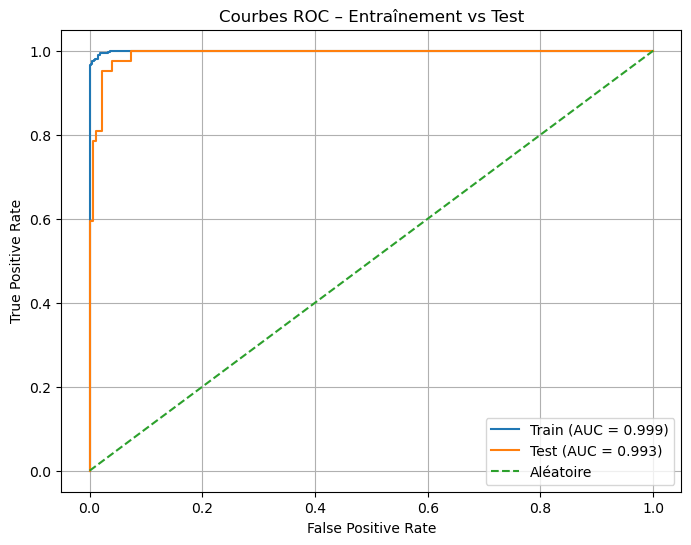

In [29]:
# Probabilités sur le jeu d'entraînement
y_train_proba = rf.predict_proba(X_train)[:, 1]

# Probabilités sur le jeu de test
y_test_proba = rf.predict_proba(X_test)[:, 1]

# Jeu d'entraînement
fpr_train, tpr_train, _ = roc_curve(y_train_enc, y_train_proba)
auc_train = roc_auc_score(y_train_enc, y_train_proba)

# Jeu de test
fpr_test, tpr_test, _ = roc_curve(y_test_enc, y_test_proba)
auc_test = roc_auc_score(y_test_enc, y_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_train, tpr_train,
    label=f"Train (AUC = {auc_train:.3f})"
)

plt.plot(
    fpr_test, tpr_test,
    label=f"Test (AUC = {auc_test:.3f})"
)

# Classifieur aléatoire
plt.plot([0, 1], [0, 1], linestyle="--", label="Aléatoire")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC – Entraînement vs Test")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


**Interprétation :**

L'aire sous la courbe de ROC est de 99.9% sur le jeu d'entraînement et 99.3% sur le jeu de test. Ces deux valeur ont un écart très faible. 
On peut conclure que le modèle est non seulement globalement satisfaisant (Bonne précision globale sur le train) mais généralise bien aussi sur des données inconnues. 

En résumé, il n'y a pas de ***sur-apprentissage*** ni de ***sous-apprentissage***. 

---

# IV Sérialisation, exemple de prédiction et construction d'une interface utilisateur de prédiction interactive

## IV.1 Sérialisation

In [30]:
# Créer un dictionnaire avec tout ce dont on a besoin
modele_a_sauvegarder = {
    'model': rf,  # votre modèle entraîné
    'colonnes': ['Moyenne Pondéré PHYSIQUE 2', 'Moyenne Pondéré MATHÉMATIQUES 2', 'Moyenne Pondéré CHIMIE 2', 'Moyenne Pondéré INFORMATIQUE 2', 'Moyenne Pondéré TRANSVERSALES 2', 'Moyenne Pondéré SCIENCES GRAPHIQUES'],  # liste des colonnes
    'date': pd.Timestamp.now(),
}

# Sauvegarder dans un fichier
joblib.dump(modele_a_sauvegarder, 'model.joblib')
print("✅ Modèle sauvegardé avec succès dans 'modele.joblib'")

✅ Modèle sauvegardé avec succès dans 'modele.joblib'


## IV.2 Exemple de prédiction

In [13]:
warnings.filterwarnings('ignore')
# Saisi des différentes notes pondérées
print("=======================================")
print("           Prédiction                  ")
print("=======================================\n")
col=['PHYSIQUE 2', 'MATHÉMATIQUES 2', 'CHIMIE 2',
     'INFORMATIQUE 2', 'TRANSVERSALES 2', 'SCIENCES GRAPHIQUES']
val=[]
for i in range(0,6):
    print(f"Saisissez la moyenne pondérée de {col[i]}")
    v=float(input())
    #if(v>=0):
        
        
    while (v<0):
        print("⚠️ Veuillez saisir une moyenne pondérée valide(moyenne>=0)")
        v=float(input())
        
    val.append(v)


def make_prediction(model, features_vector):
    
    # Convertir en format approprié (2D array)
    features_array = np.array(features_vector).reshape(1, -1)
    
    # Faire la prédiction
    prediction = model.predict(features_array)[0]
    proba = model.predict_proba(features_array)[0]
    
    # Afficher les résultats
    print("=" * 50)
    print("📊 RÉSULTATS DE LA PRÉDICTION")
    print("=" * 50)
    print(f"Caractéristiques: {features_vector}")
    print(f"Prédiction: {'✅ Validé' if prediction == 1 else '❌ Non validé'}")
    #print(f"Probabilités: {proba}")
    print(f"- Probabilité de ne pas validé: {proba[0]:.2%}")
    print(f"- Probabilité de validé: {proba[1]:.2%}")
    #print("=" * 50)
    
    #return prediction, proba

# Chargement du modèle
loaded_data = joblib.load("model.joblib")

model = loaded_data['model'] 
make_prediction(model, val)

# Exemple de données "Validé" : 92,5	12  40,75 	82	73	30
# Exemple de données "Non validé" : 74	11,5  60,5	49 	58	21


           Prédiction                  

Saisissez la moyenne pondérée de PHYSIQUE 2


 45


Saisissez la moyenne pondérée de MATHÉMATIQUES 2


 -4


⚠️ Veuillez saisir une moyenne pondérée valide(moyenne>=0)


 23


Saisissez la moyenne pondérée de CHIMIE 2


 98


Saisissez la moyenne pondérée de INFORMATIQUE 2


 78


Saisissez la moyenne pondérée de TRANSVERSALES 2


 93


Saisissez la moyenne pondérée de SCIENCES GRAPHIQUES


ValueError: could not convert string to float: ''

## V.3 Interface utilisateur de prédiction

Nous avons construite une interface graphique de prédiction utilisant la librairie streamlit.

# Conclusion

En résumé, nous avons construit un modèle d'apprentissage machine pour la prédiction des résultats de sessions estudiantines. Ce modèle, utilisant des caractéristiques liées au notes d'évaluations des étudiants est capable de réaliser la prédiction avec une grande précision, limitant ainsi les erreurs. Nous avons également construit une interface interactive pour simplifier l'utilisation du modèle.

Il serait plus judicieux d'avoir plus de données et plus de diversité dans les données pour extraire le maximum de caractéristiques car le domaine d'application est très sensible aux erreurs.